# Processing of gene expression modality using Scanpy

For this tutorial, we are processing the medulloblastoma mouse model single cell multiome data from:

_Shiraishi, R. & Cancila, G. et al. (2024). Cancer-specific epigenome identifies oncogenic hijacking by nuclear factor I family proteins for medulloblastoma progression. Dev. Cell , 59:2302-2319._

This data set contains three samples comprising FACS sorted cells. These cells reflect the progression from healthy precursors to tumor cells:

1. Ptch1GNP: granule neuron precursors, P7
2. PNC: preneoplastic cells, P28
3. Tumor: tumor cells, adult mice

Data was downloaded from the Gene Expression Omnibus:

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE240362

The `GSE240362_RAW.tar` file contains the raw gene expression counts files in HDF5 format (.h5). This is the typical output you would obtain from the [10X Genomics Cellranger software](https://www.10xgenomics.com/support/software/cell-ranger/latest/getting-started/cr-what-is-cell-ranger).

The raw counts are processed with _Scanpy_.

For additional information on processing single cell data, see:
* https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html
* https://www.sc-best-practices.org/preamble.html


First, we assign the sample names to the different file names.

In [1]:
samples = ['Ptch1GNP', 'PNC', 'Tumor']

paths_adata = ['/storage/nhecker/embl/GSE240362/GSM7791840_032103_filtered_feature_bc_matrix.h5',
              '/storage/nhecker/embl/GSE240362/GSM7791842_RS03056_filtered_feature_bc_matrix.h5',
              '/storage/nhecker/embl/GSE240362/GSM7791844_RS03060_filtered_feature_bc_matrix.h5']

We read the counts file of each sample and combine them in a list called adatas. To avoid issues with duplicated gene names, we call the function `var_names_make_unique` and assign the sample as cell metadata.

In [2]:
import scanpy as sc

adatas = [ sc.read_10x_h5(path) for path in paths_adata]
for i, sample in enumerate(samples):
    adatas[i].var_names_make_unique()
    adatas[i].obs['sample'] = sample

/opt/venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


For example, for the first sample each cell barcode with be assigned to sample 'Ptch1GNP'.

In [3]:
adatas[0].obs

,sample
AAACAGCCAAAGGTAC-1,Ptch1GNP
AAACAGCCAATGCCCG-1,Ptch1GNP
AAACAGCCACCTCACC-1,Ptch1GNP
AAACAGCCACGAACAG-1,Ptch1GNP
AAACAGCCATAATCAC-1,Ptch1GNP
...,...
TTTGTTGGTAGACAAA-1,Ptch1GNP
TTTGTTGGTGCTAGAC-1,Ptch1GNP
TTTGTTGGTGGAGCAA-1,Ptch1GNP
TTTGTTGGTGTGTGGT-1,Ptch1GNP


The count data of each sample is stored in separate AnnData object at this stage. They contain between 7,212 and 11,924 cells per sample and information for 32,285 genes or transcripts.

In [4]:
adatas

[AnnData object with n_obs × n_vars = 7212 × 32285
     obs: 'sample'
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 11924 × 32285
     obs: 'sample'
     var: 'gene_ids', 'feature_types', 'genome',
 AnnData object with n_obs × n_vars = 10594 × 32285
     obs: 'sample'
     var: 'gene_ids', 'feature_types', 'genome']

## Doublet detection

Doublets are artefacts that can occur during single cell experiments. For single cell experiements, a single cell should be mixed with a cell barcode in a droplet before the sequecing steps. However, it can occur that two or more cells get mixed up in the same droplets. These artefacts are called doublets and can be detected with methods like _Scrublet_: 

_Wolock, S. L., Lopez, R., & Klein, A. M. (2019). Scrublet: computational identification of cell doublets in single-cell transcriptomic data. Cell systems, 8:281-291._

For more information, see:

https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html

Here, we use the _Scrublet_ implementation in _Scanpy_ to check for doublets. _Scrublet_ is simulating mixed transcriptomics and uses a KNN classifer for detecting doublets. Ideally, we should see a bimodial distribution of transcriptomes to reliable set a doublet threshold.

/opt/venv/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:155: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.58
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


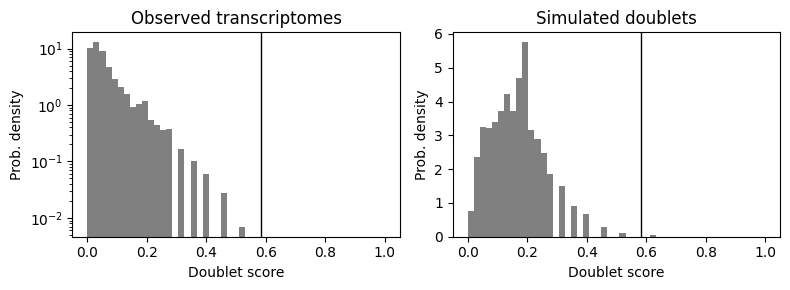

/opt/venv/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:155: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.49
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.0%


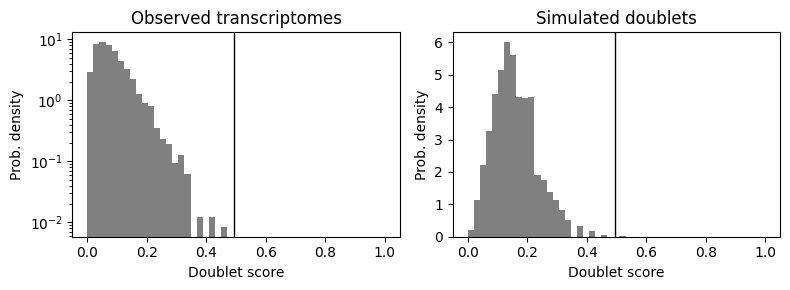

/opt/venv/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:155: UserWarning: Revieved a view of an AnnData. Making a copy.
  view_to_actual(adata)


Automatically set threshold at doublet score = 0.56
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.1%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 18.2%


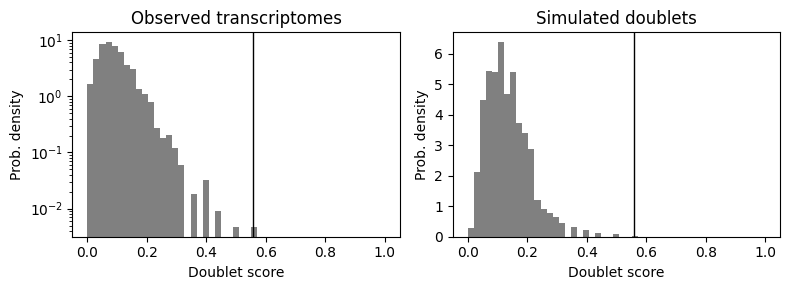

In [5]:
# run scrublet
for i, sample in enumerate(samples):
    sc.external.pp.scrublet(adatas[i])
    # convert bool into string to avoid anndata format issue during saving
    adatas[i].obs['predicted_doublet'] = [str(dbl) for dbl in adatas[i].obs['predicted_doublet']]
    sc.external.pl.scrublet_score_distribution(adatas[i])
    

In this case, we cannot reliably detect doublets as we do not observe a bimodial distribution. However, it might still be interesting to store the doublet scores to investigate tendencies for doublets in our data set.

# QC

Before we perform quality control, we are concatenating our three anndata objects into a single object. Since these data sets potentially contain the same barcodes for different cells, we add  the sample name to each cell after the separator '__'.

In [6]:
# concatenate
import anndata as ann

adata = ann.concat(adatas, keys=samples, index_unique='__')

In [7]:
adata.obs

,sample,doublet_score,predicted_doublet
AAACAGCCAAAGGTAC-1__Ptch1GNP,Ptch1GNP,0.112527,False
AAACAGCCAATGCCCG-1__Ptch1GNP,Ptch1GNP,0.010193,False
AAACAGCCACCTCACC-1__Ptch1GNP,Ptch1GNP,0.017131,False
AAACAGCCACGAACAG-1__Ptch1GNP,Ptch1GNP,0.202797,False
AAACAGCCATAATCAC-1__Ptch1GNP,Ptch1GNP,0.051130,False
...,...,...,...
TTTGTTGGTAACCTAG-1__Tumor,Tumor,0.040000,False
TTTGTTGGTACTGATG-1__Tumor,Tumor,0.166870,False
TTTGTTGGTATTCGTC-1__Tumor,Tumor,0.074952,False
TTTGTTGGTATTGTGG-1__Tumor,Tumor,0.066121,False


In [8]:
adata

AnnData object with n_obs × n_vars = 29730 × 32285
    obs: 'sample', 'doublet_score', 'predicted_doublet'

Among the number of genes and counts, the percentage of mitochondrial genes, ribosomal genes, and hemoglobin genes are quality indicators for cells. For cancer and other pathological tissues, the percentage of mitochondrial genes might be inflated though due to biological processes. Given that we are working with cancer tissues, we compute these quality metrics but do not apply strict filtering.

In [9]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("mt-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("rps", "rpl"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^hb[^(p)]")

In [10]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:835: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:835: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:835: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:835: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  a

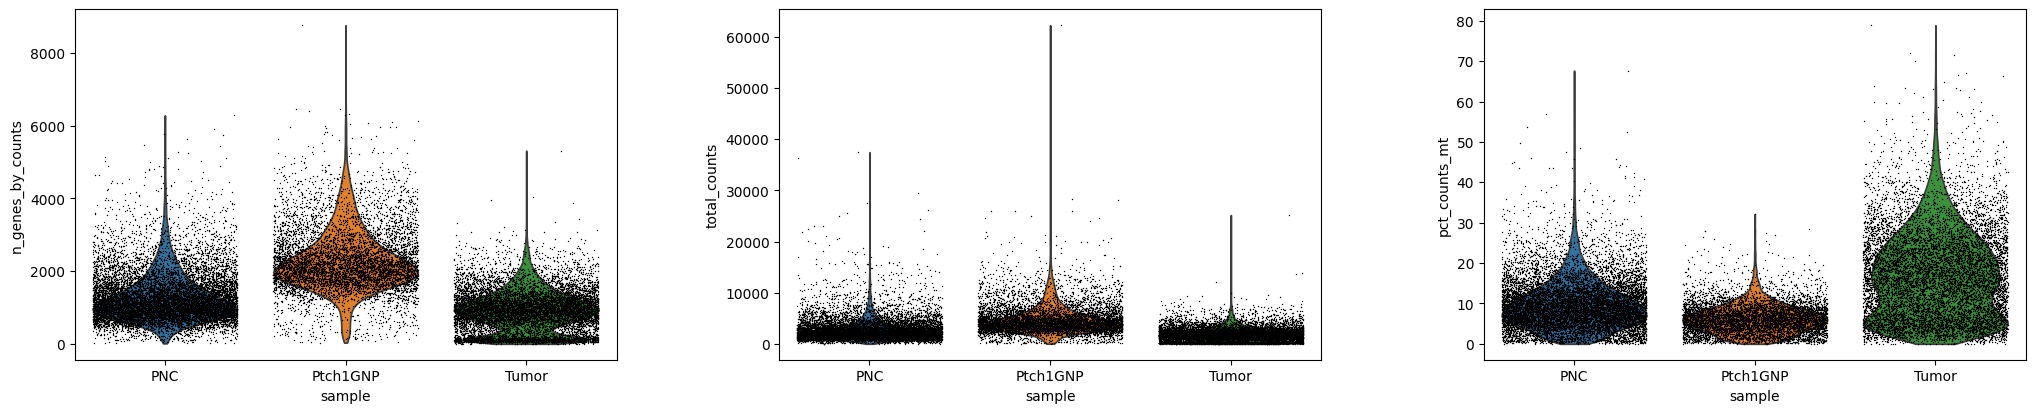

In [11]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    groupby='sample',
)

To remove empty or nearly empty cells and genes that have no notable expression in most of the cells, we apply relaxed filtering criteria for cells and genes.

In [12]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [13]:
adata

AnnData object with n_obs × n_vars = 28980 × 23280
    obs: 'sample', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'sample_colors'

The raw counts will be modified in the downstream processing. To keep their initial values, we store them in a layer called `counts`. _SCENIC+_ requires us in addition to store the object with raw counts in `.raw`.

In [14]:
# Saving count data
adata.layers["counts"] = adata.X.copy()
adata.raw = adata

# Clustering

Before we cluster our data, we log-normalise the counts.

In [15]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

Next, we identify the most highly variable genes in the data set.

In [16]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

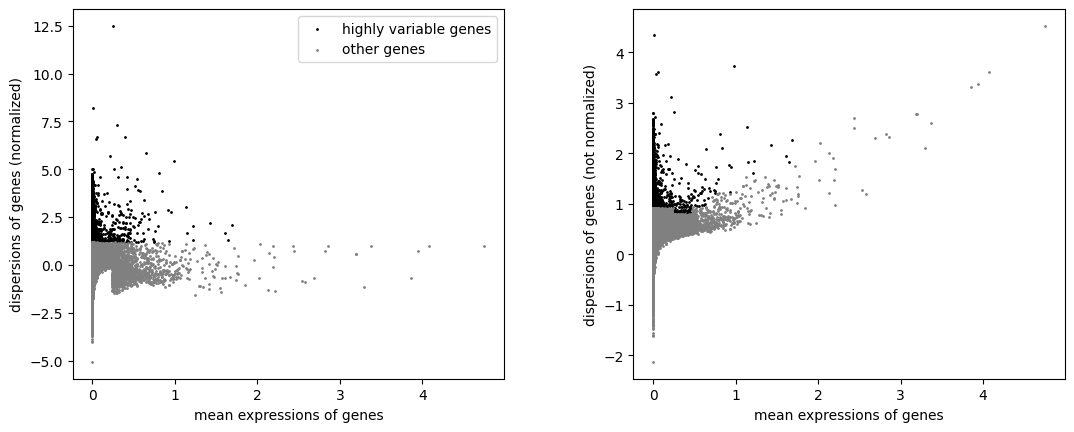

In [17]:
sc.pl.highly_variable_genes(adata)

Principial component analysis (PCA) is performed to reduce the dimensionality of our dataset. Per default the PCA in _Scanpy_ is limited to the highly variable genes.

In [18]:
sc.tl.pca(adata)

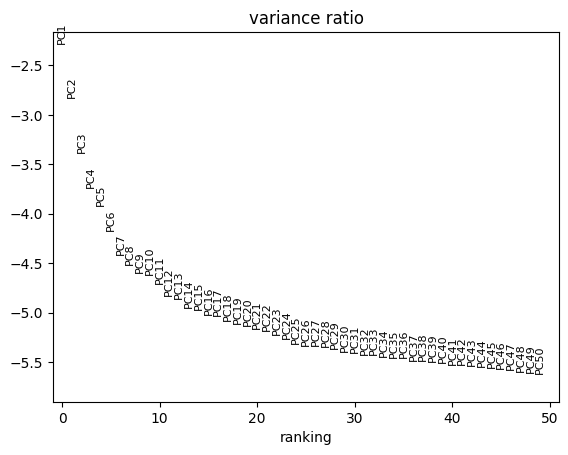

In [19]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

PC loadings provide an idea about the most interesting genes in the dataset.

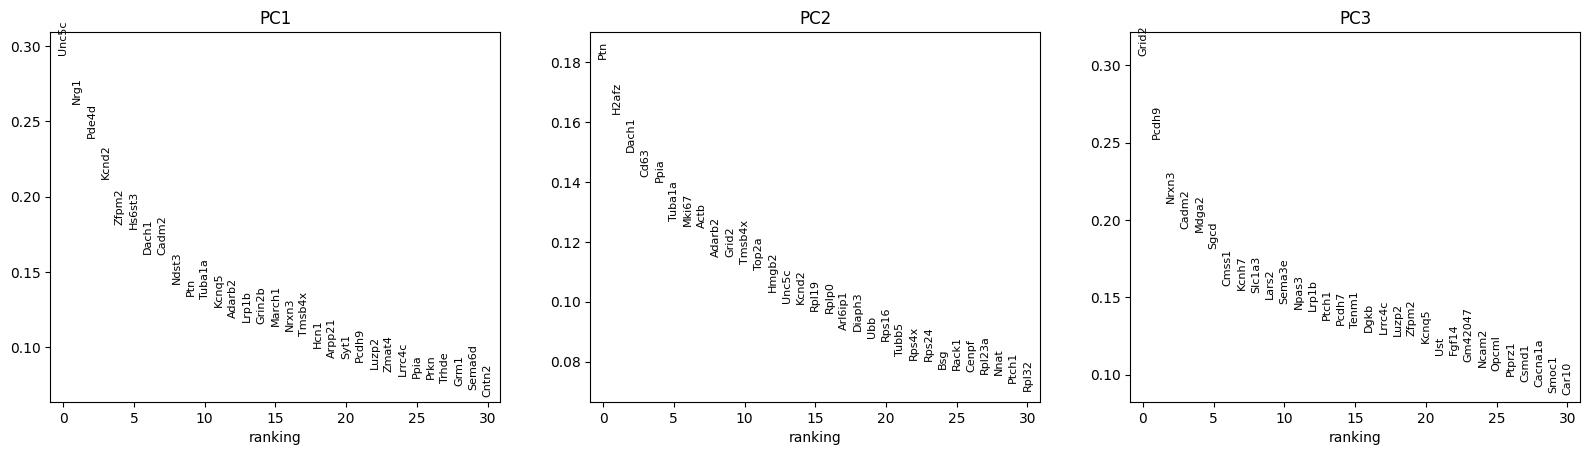

In [20]:
sc.pl.pca_loadings(adata, include_lowest=False)

By plotting the first two principal components, we already see that tumor cells (`PNC` and `Tumor`) are more similar to each other than the neuron precursor cells (`Ptch1GNP`). We also can observed a higher percentage of mitochondrial genes in the `Tumor` sample, as expected.

/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


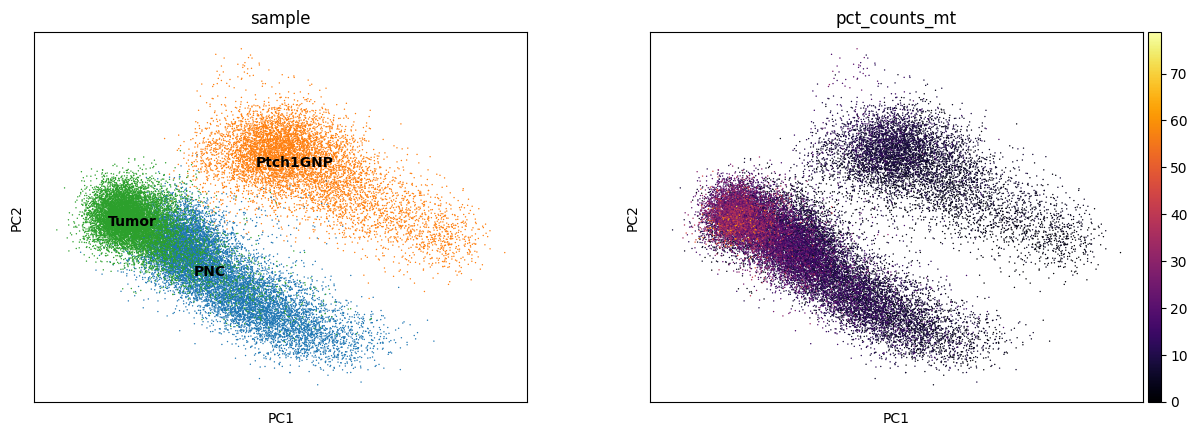

In [21]:
sc.pl.pca(
    adata, color=['sample', 'pct_counts_mt'], legend_loc = 'on data', cmap='inferno'
)

To perform clustering and to visualise the data in a UMAP, we compute a nearest neighbor graph.

In [22]:
sc.pp.neighbors(adata)

/opt/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
sc.tl.umap(adata)

Similarly to investigating the principal components, we see cells clustering together per sample in the UMAP. There are additional sub clusters.

/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


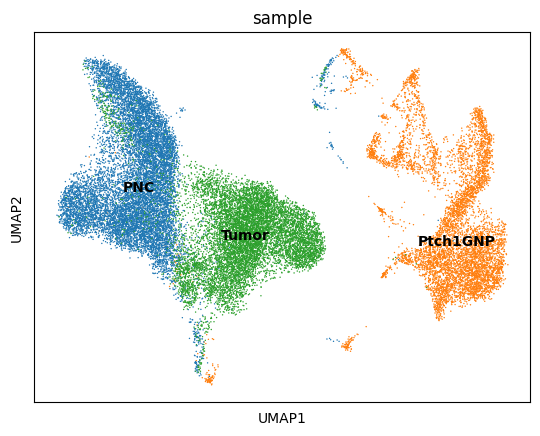

In [24]:
sc.pl.umap(adata, color=["sample"], legend_loc = 'on data')

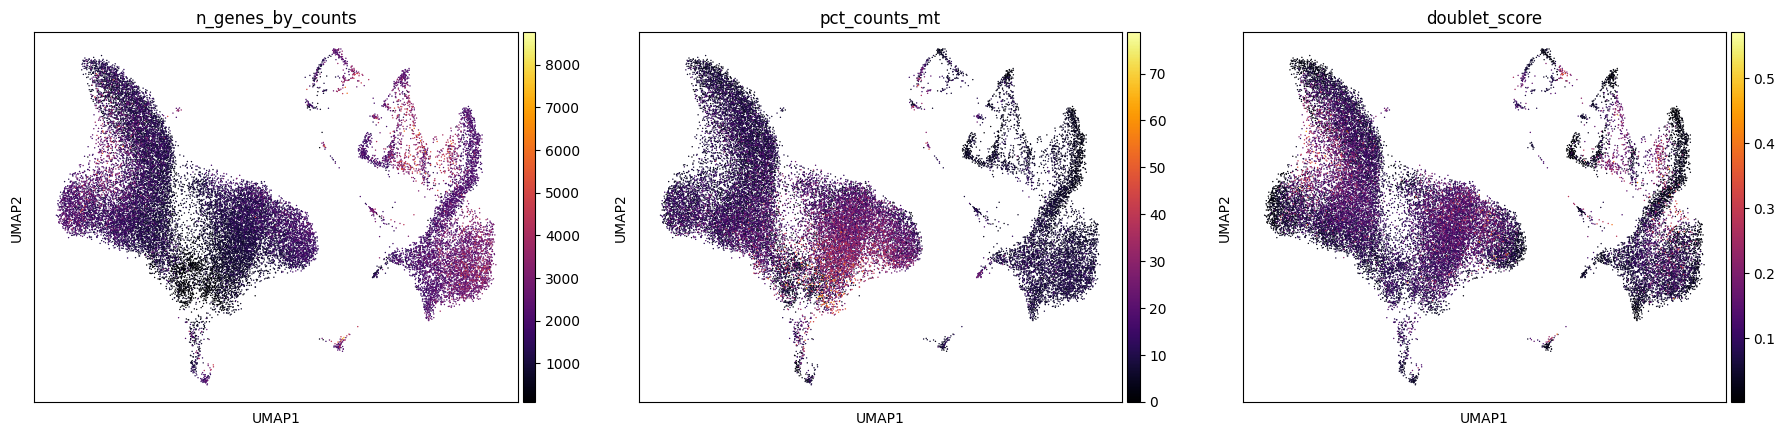

In [25]:
sc.pl.umap(adata, color=['n_genes_by_counts', 'pct_counts_mt', 'doublet_score'], legend_loc = 'on data', cmap='inferno')

There is trivial way of picking a perfect clustering resolution. Hence, we compute clusters at several different resolutions.

In [26]:
clus_resolutions = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0]

for resolution in clus_resolutions:
    print(f"Clustering resolution {resolution} ...")
    sc.tl.leiden(adata, resolution=resolution, key_added='leiden_' + str(resolution) )
print(f"ALL DONE.")

Clustering resolution 0.1 ...
Clustering resolution 0.25 ...
Clustering resolution 0.5 ...
Clustering resolution 0.75 ...
Clustering resolution 1.0 ...
Clustering resolution 1.5 ...
Clustering resolution 2.0 ...
Clustering resolution 2.5 ...
Clustering resolution 3.0 ...
ALL DONE.


/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/venv/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:378: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/opt/venv/lib/python3.11/site-packages/scanpy/plot

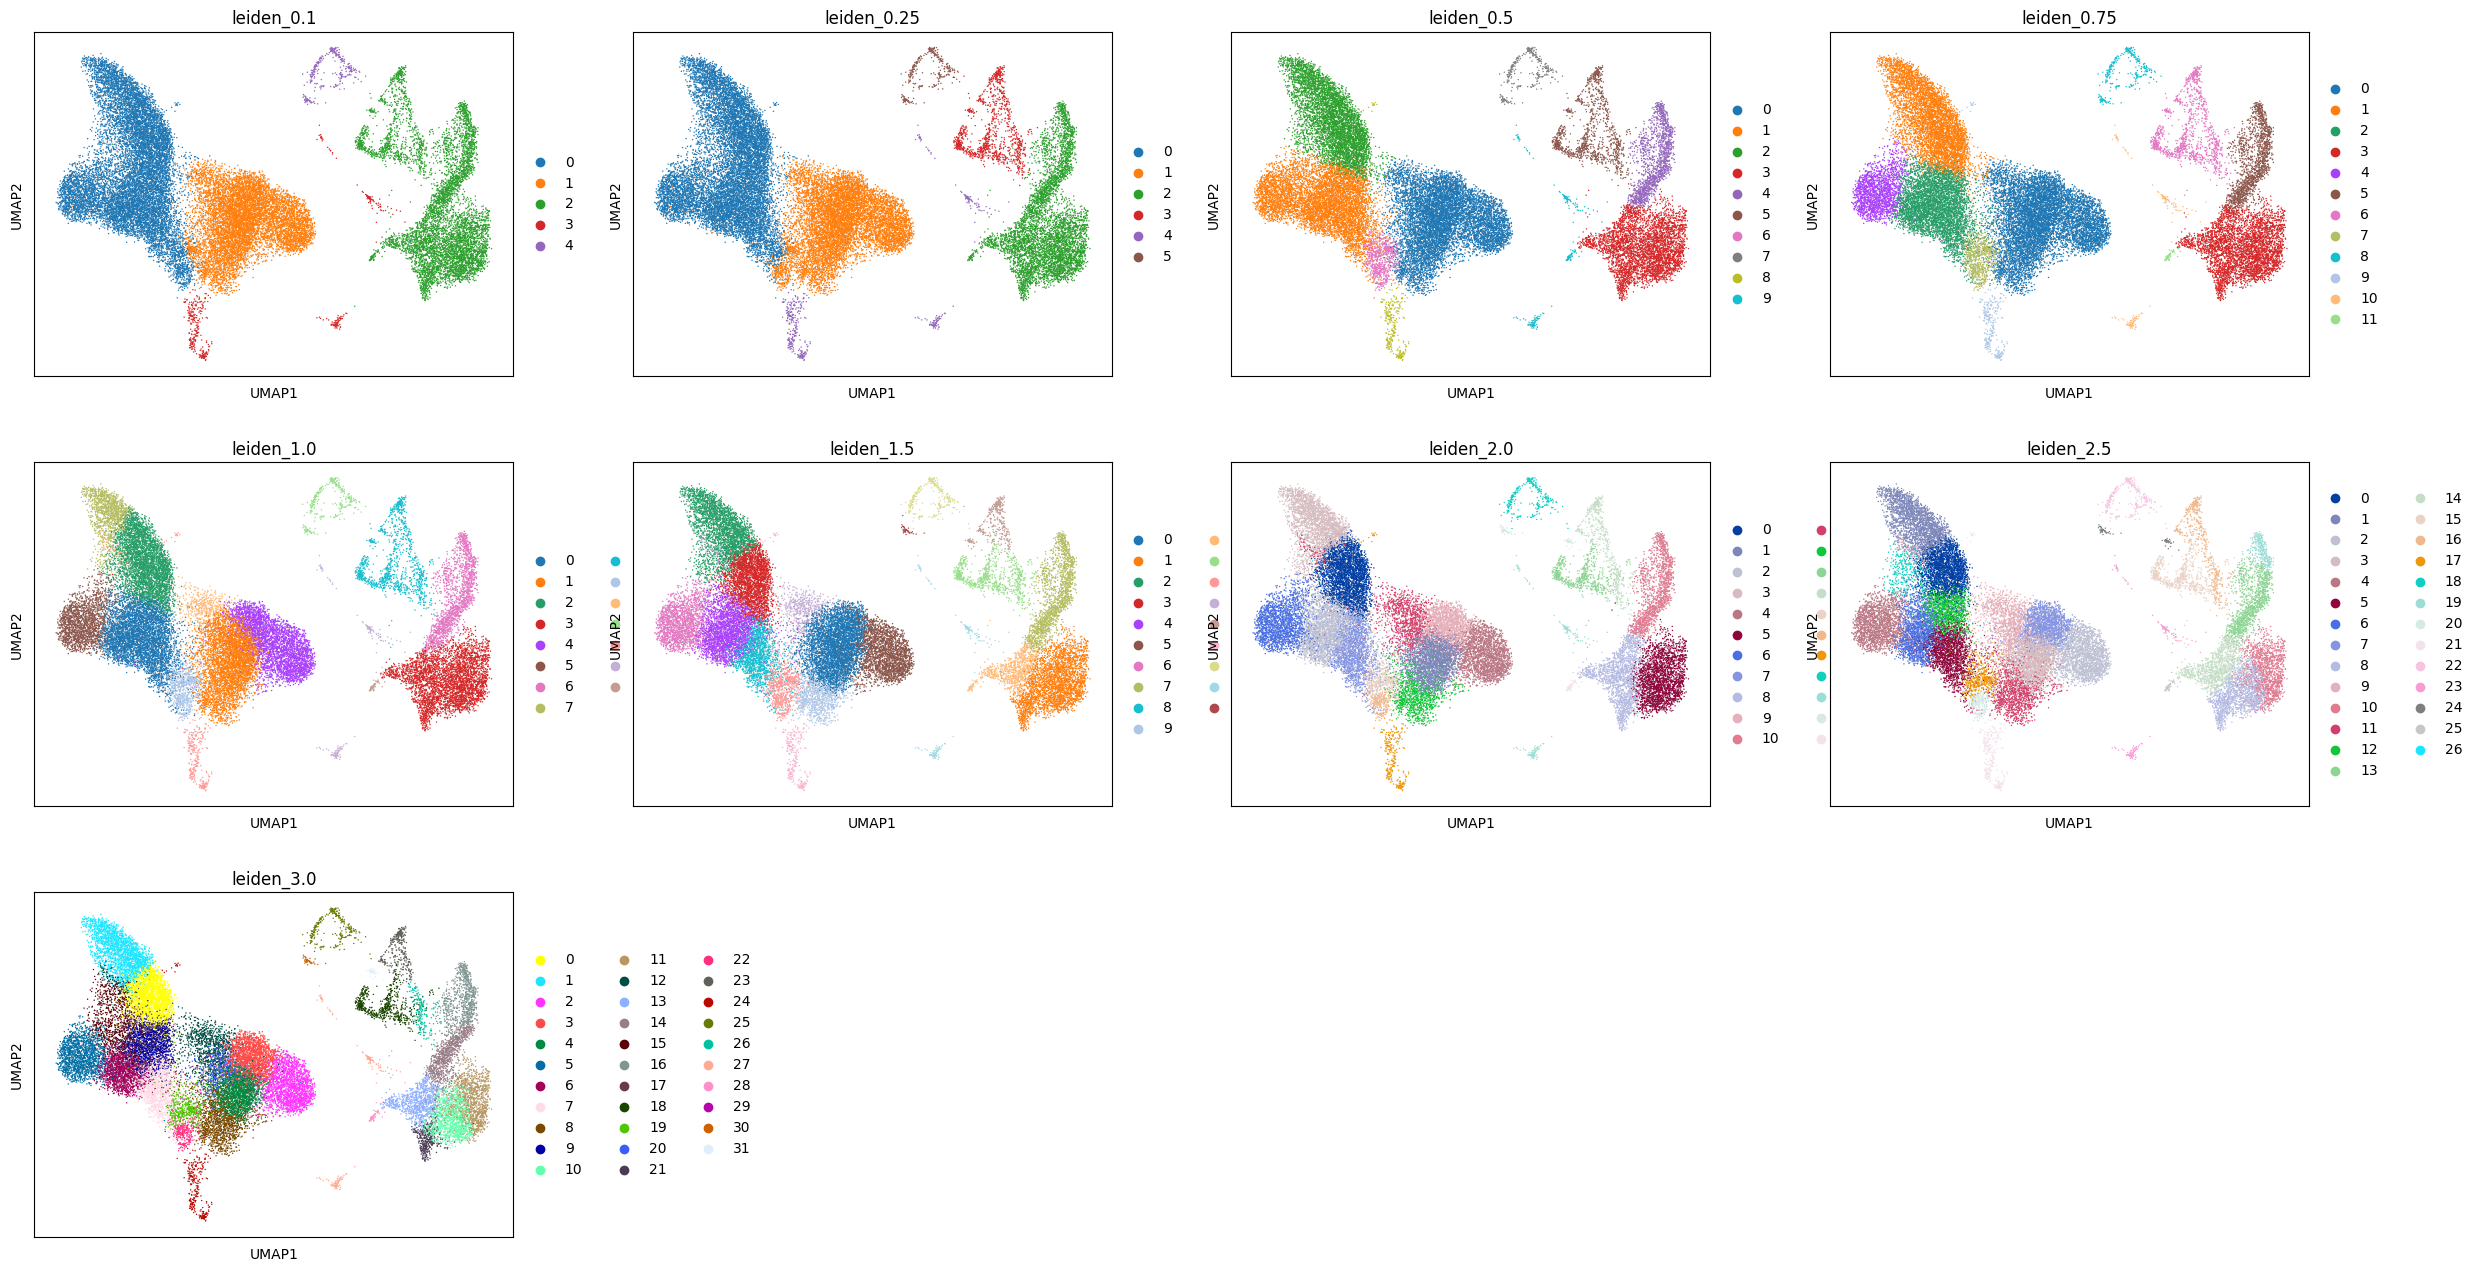

In [27]:
sc.pl.umap(adata, color=['leiden_' + str(resolution) for resolution in clus_resolutions])

A resolution of 0.5 is a good choice for this dataset to capture some within-sample-variation in the clusters and not to over-cluster our data. This choice remains arbitrary though and depends the research question whether we are interested into more fine-grained or coarse clusters.

All clusters for the different resolutions are given in the `obs` cell meta data.

In [28]:
adata.obs

,sample,doublet_score,predicted_doublet,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,...,n_genes,leiden_0.1,leiden_0.25,leiden_0.5,leiden_0.75,leiden_1.0,leiden_1.5,leiden_2.0,leiden_2.5,leiden_3.0
AAACAGCCAAAGGTAC-1__Ptch1GNP,Ptch1GNP,0.112527,False,2327,7.752765,4287.0,8.363576,19.594122,25.705622,34.219734,...,2327,2,2,3,3,3,1,5,8,10
AAACAGCCAATGCCCG-1__Ptch1GNP,Ptch1GNP,0.010193,False,1624,7.393263,3181.0,8.065266,24.740648,32.977051,43.791261,...,1624,2,2,4,5,6,7,10,13,14
AAACAGCCACCTCACC-1__Ptch1GNP,Ptch1GNP,0.017131,False,3436,8.142354,8641.0,9.064389,21.444277,28.457354,37.044324,...,3436,4,5,7,8,11,16,18,22,25
AAACAGCCACGAACAG-1__Ptch1GNP,Ptch1GNP,0.202797,False,4443,8.399310,11592.0,9.358157,19.142512,25.258799,32.962388,...,4443,2,3,5,6,8,11,13,15,18
AAACAGCCATAATCAC-1__Ptch1GNP,Ptch1GNP,0.051130,False,1868,7.533159,3699.0,8.216088,25.574480,32.197891,41.605839,...,1868,2,2,3,3,3,1,8,8,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTAACCTAG-1__Tumor,Tumor,0.040000,False,1025,6.933423,1979.0,7.590852,33.956544,42.546741,53.764528,...,1025,1,1,0,0,10,13,11,9,12
TTTGTTGGTACTGATG-1__Tumor,Tumor,0.166870,False,1415,7.255591,2690.0,7.897668,31.040892,38.066914,47.546468,...,1415,1,1,0,0,4,5,9,7,3
TTTGTTGGTATTCGTC-1__Tumor,Tumor,0.074952,False,407,6.011267,1080.0,6.985642,65.925926,71.574074,80.833333,...,407,1,1,0,0,1,0,12,11,8
TTTGTTGGTATTGTGG-1__Tumor,Tumor,0.066121,False,843,6.738152,1492.0,7.308543,34.182306,43.230563,56.635389,...,843,1,1,0,0,4,0,9,9,3


Finally, we save the object.

In [29]:
import os

outdir = '/storage/nhecker/embl/GSE240362/scanpy'
outf = outdir + '/rna_medulloblastoma.h5ad'

os.makedirs(outdir, exist_ok=True)
adata.write(outf)
print(outf)

/storage/nhecker/embl/GSE240362/scanpy/rna_medulloblastoma.h5ad
